# Timeseries forecast model
This notebook contains some timeserie models that aim to outperform the baseline model (see nb_baseline_model). The baseline model is a weighted average (seasonal) timeseries forecast for the next 4 quarters.

The data is limited to 2014 and onwards, so that we have a prediction for the last 10 years (2015-2025). This can be changed by adjusting the where clause in the SQL statement.

In the bottom section of the notebook the timeseries prediction is visualised for three groups of SBI codes:
- Total aggregated absenteeism (sbi=T001081)
- Absenteeism per SBI category (sbi lvl1, category A, B C etc.)
- Absenteeism per company size (sbi=WP19098,WP19091, WP19078)

## 1. Data preparation

In [127]:
import sys
import os
from pathlib import Path
import pickle
import json
# Add project root to sys.path to allow imports from src
sys.path.append(str(Path(os.getcwd()).parent.parent))
from sqlalchemy import create_engine
import warnings
import pandas as pd
import numpy as np
from scipy import stats
from itertools import product
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import statsmodels
from statsmodels.tsa.seasonal import STL                    # STL stays here ✅
from statsmodels.tsa.forecasting.stl import STLForecast     # STLForecast is here ✅
from statsmodels.tsa.arima.model import ARIMA               # also updated
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsforecast import StatsForecast
from statsforecast.models import AutoETS

from config import DIR_DB_SILVER, DIR_DB_GOLD
from src.utils.m_nb_results_to_gold_export import f_nb_results_to_gold_export, f_list_gold_tables
from src.utils.m_query_database import f_query_database

# Settings — pandas display options 
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)       # Show all columns
pd.set_option("display.max_rows", 20)            # Show 20 rows
pd.set_option("display.width", 10000)            # Prevent truncation due to width limit
pd.set_option("display.float_format", "{:.2f}".format)

# Visualisation variables
covid_start = pd.Timestamp('2020-03-31') # Q1 2020
covid_end = pd.Timestamp('2022-06-30')   # Q2 2022

# Get baseline model results from gold
query = """ SELECT * FROM prediction_baseline_total"""
df_baseline_total = f_query_database(DIR_DB_GOLD, query, "pandas")
df_baseline_total["period_enddate"] = pd.to_datetime(df_baseline_total["period_enddate"])
print(f"✅ Success! Loaded {len(df_baseline_total)} rows.")

# Get precalculated STL and ETS settings
CV_OUTPUT_DIR = Path("cv_output")
# STL+ETS CV results
df_cv = pd.read_parquet(CV_OUTPUT_DIR / "cv_results.parquet")
cv_summary = pd.read_parquet(CV_OUTPUT_DIR / "cv_summary.parquet")

# Get same dataset as baseline model
# SQL Query to extract and format absenteeism data
query = """ 
SELECT 
    Perioden as timeperiod_text, 
    BedrijfskenmerkenSBI2008  as sbi_code,
    BedrijfskenmerkenSBI2008_Title as sbi_title,
    DATE(
        printf('%s-%s-01', 
            substr(Perioden, 1, 4), 
            CASE substr(Perioden, 7, 2)
                WHEN '01' THEN '01'
                WHEN '02' THEN '04'
                WHEN '03' THEN '07'
                WHEN '04' THEN '10'
            END
        ), 
        '+3 months', 
        '-1 day'
    ) AS period_enddate,
    CAST(substr(Perioden, 1, 4) as INTEGER) as "year",
    CAST(substr(Perioden, 8, 1) as INTEGER) as "quarter",
    CAST(Ziekteverzuimpercentage_1 AS REAL) as absenteeism_perc
FROM "80072ned_silver"
WHERE Perioden NOT LIKE '%JJ%' 
AND substr(Perioden, 1, 4) >= '2012'
order by sbi_code, Period_enddate asc
"""
df_org = f_query_database(DIR_DB_SILVER, query, "pandas")
print(f"✅ Success! Loaded {len(df_org)} rows.")

# --- Type Casting ---
# parse_dates already handles period_enddate; cast remaining columns explicitly
df_org["year"] = df_org["year"].astype(int)
df_org["quarter"] = df_org["quarter"].astype(int)
df_org["absenteeism_perc"] = pd.to_numeric(df_org["absenteeism_perc"], errors="coerce")
df_org["period_enddate"] = pd.to_datetime(df_org["period_enddate"])
# Keep a clean copy as df_modified (mirrors the original variable name)
df_modified = df_org.copy()

# --- Split into three DataFrames for different analyses ---
df_total = (
    df_modified[df_modified["sbi_code"] == "T001081"]
    .copy()
    .sort_values("period_enddate")
    .reset_index(drop=True)
)

df_sbi_lvl1 = (
    df_modified[df_modified["sbi_title"].str.upper().str.contains(r"^[A-U]\s", regex=True)]
    .copy()
    .reset_index(drop=True)
)

df_compsize = (
    df_modified[df_modified["sbi_code"].isin(["WP19098", "WP19091", "WP19078"])]
    .copy()
    .reset_index(drop=True)
)

# Quick look at the most recent rows
print(df_total.sort_values("period_enddate", ascending=False).head())

✅ Success! Loaded 55 rows.
✅ Success! Loaded 2145 rows.
   timeperiod_text sbi_code                          sbi_title period_enddate  year  quarter  absenteeism_perc
54        2025KW03  T001081  A-U Alle economische activiteiten     2025-09-30  2025        3              5.10
53        2025KW02  T001081  A-U Alle economische activiteiten     2025-06-30  2025        2              5.20
52        2025KW01  T001081  A-U Alle economische activiteiten     2025-03-31  2025        1              5.80
51        2024KW04  T001081  A-U Alle economische activiteiten     2024-12-31  2024        4              5.40
50        2024KW03  T001081  A-U Alle economische activiteiten     2024-09-30  2024        3              4.90


## 2. STL with ETS  

In [128]:
# --- Step 2: Prepare df_total as a proper time series ---
# Set period_enddate as the index — STL needs a datetime index
df_ts = (
    df_total
    .set_index("period_enddate")["absenteeism_perc"]
    .asfreq("QE")  # QE = Quarter End frequency; enforces regularity
)
# What asfreq("QE") does: It forces pandas to recognize this as quarterly data ending on the last day of each quarter. 
# If any quarter is missing, it inserts a NaN — which alerts you immediately rather than silently corrupting your model. 
# If you have NaNs, you'd interpolate: ts = ts.interpolate(method="time").

# Quick sanity check
print(f"Time series length: {len(df_ts)} quarters")
print(f"Start: {df_ts.index.min().date()}  |  End: {df_ts.index.max().date()}")
print(f"Missing values: {df_ts.isna().sum()}")
print(df_ts.tail(8))

Time series length: 55 quarters
Start: 2012-03-31  |  End: 2025-09-30
Missing values: 0
period_enddate
2023-12-31   5.50
2024-03-31   5.50
2024-06-30   5.10
2024-09-30   4.90
2024-12-31   5.40
2025-03-31   5.80
2025-06-30   5.20
2025-09-30   5.10
Freq: QE-DEC, Name: absenteeism_perc, dtype: float64


### 2.1 Visual exploration
A quick visual inspection to see the trend and seasonal pattern

Component magnitudes (std dev):
  Seasonal:  0.2983
  Trend:     0.5912
  Residual:  0.1745
--- STL Correction Scorecard ---
Residual Noise (StdDev): 0.1745 (Lower is better)
Trend Strength:          0.9248 (Higher is better)
Seasonal Strength:       0.7500 (Higher is better)
Ljung-Box p-value:       0.3785 (>0.05 means residuals are random)


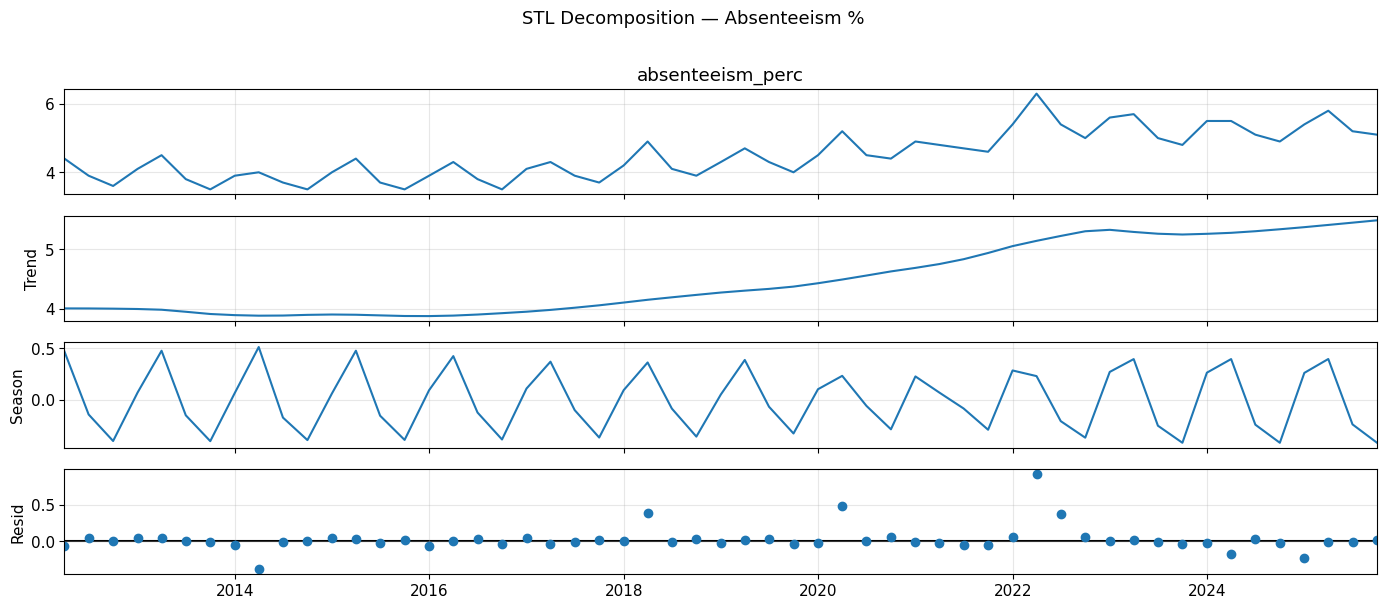

In [129]:
# STL Decomposition (inspect only, no forecast yet) ---
stl = STL(
    df_ts,
    period=4,          # 4 quarters = 1 full seasonal cycle
    seasonal=5,        # seasonal smoother window — nested CV consistently preferred 5
    seasonal_deg=0,    # constant seasonal smoother — won every single outer fold
    robust=True        # downweight outliers like COVID spikes
)
stl_result = stl.fit()

print("Component magnitudes (std dev):")
print(f"  Seasonal:  {stl_result.seasonal.std():.4f}")
print(f"  Trend:     {stl_result.trend.std():.4f}")
print(f"  Residual:  {stl_result.resid.std():.4f}")
# 1. Standard Deviation
res_std = stl_result.resid.std()
# 2. Strength of Trend and Seasonality
def calc_strength(comp, resid):
    return max(0, 1 - (np.var(resid) / np.var(comp + resid)))
strength_t = calc_strength(stl_result.trend, stl_result.resid)
strength_s = calc_strength(stl_result.seasonal, stl_result.resid)
# 3. Randomness (Ljung-Box) - we check if residuals are white noise
lb_test = acorr_ljungbox(stl_result.resid, lags=[4], return_df=True)
lb_pvalue = lb_test['lb_pvalue'].iloc[0]
print(f"--- STL Correction Scorecard ---")
print(f"Residual Noise (StdDev): {res_std:.4f} (Lower is better)")
print(f"Trend Strength:          {strength_t:.4f} (Higher is better)")
print(f"Seasonal Strength:       {strength_s:.4f} (Higher is better)")
print(f"Ljung-Box p-value:       {lb_pvalue:.4f} (>0.05 means residuals are random)")

stl_result.plot()
plt.suptitle("STL Decomposition — Absenteeism %", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 2.2 STL Forecast
We combine the STL decomposition of trend and seasonality with an ETS forecasting model for the residuals. 

**Note:** The STL Decomposition in the previous step is NOT directly used by following STLForecast function.
That's because STLForecast runs its own internal STL decomposition "under the hood". The previous STL + .fit() is purely for visual inspection / diagnostic. STLForecast takes the same df_ts as input and then internally runs STL itself with the same parameters as part of its fitting process.

#### NESTED WALK FORWARD CROSS-VALIDATION LOOP EXPLAINED
Standard cross-validation randomly shuffles data into train/test splits. That is WRONG for time series — it means that you are mean training on 2022 data to predict 2019, that's data leakage. Walk-forward validation enforces temporal integrity by always training on data that would have been available at that point in time.
─────────────────────────────────────────────────────►  time

FOLD 1:  [■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■]  □
          ↑ training data           ↑ predict this one point

FOLD 2:  [■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■]  □
          ↑ training data grows      ↑ predict this one point

FOLD 3:  [■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■]  □
          ↑ training data grows again ↑ predict this one point

         ■ = training data
         □ = the one point being predicted (never seen during training)

In [130]:
df_cv_stl = pd.read_parquet(CV_OUTPUT_DIR / "cv_results.parquet")
cv_summary = pd.read_parquet(CV_OUTPUT_DIR / "cv_summary.parquet")

# --- Load winning config ---
with open(CV_OUTPUT_DIR / "best_config.pkl", "rb") as f:
    config = pickle.load(f)

df_ts_corrected = config["df_ts_corrected"]
best_params     = config["best_params"]
best_stl_params = config["best_stl_params"]
mae_stl         = config["mae_stl"]
rmse_stl        = config["rmse_stl"]
mape_stl        = config["mape_stl"]

print(f"✅ Loaded CV results: {len(df_cv_stl)} records")
print(f"🏆 Winning correction: {config['winning_correction']}")
print(f"   ETS:  {best_params}")
print(f"   STL:  {best_stl_params}")
print(f"   MAE:  {mae_stl:.3f}  |  RMSE: {rmse_stl:.3f}  |  MAPE: {mape_stl:.1f}%")

✅ Loaded CV results: 806 records
🏆 Winning correction: no_correction|winsorized
   ETS:  {'error': 'mul', 'trend': None, 'damped_trend': np.False_}
   STL:  {'seasonal': 11, 'seasonal_deg': 0}
   MAE:  0.189  |  RMSE: 0.274  |  MAPE: 3.6%


In [131]:
## Final prediction
# quarters to forecast, baseline model is year-on-year, so N_forecast is 4 quarters.
n_forecast = 4
m_STL_final = STLForecast(
    df_ts_corrected,          # fit model on all data to make a prediction for next 4 quarters
    model=ETSModel,           
    model_kwargs={**best_params, "seasonal": None},
    period=4,
    **best_stl_params,
    robust=True
)

# 1. Fit the STLForecast model
final_fit = m_STL_final.fit()

# 2. Use get_prediction (the correct method for ETS)
forecast_res = final_fit.model_result.get_prediction(
    start=len(df_ts), 
    end=len(df_ts) + n_forecast - 1
)

# 3. Get the summary frame
forecast_df = forecast_res.summary_frame(alpha=0.05)

# Honest check: Print columns if you want to verify
# print(forecast_df.columns) 

# 4. Build the final DataFrame using 'pi_lower' and 'pi_upper'
df_forecast = pd.DataFrame({
    "forecast":  final_fit.forecast(n_forecast).round(2),
    "lower_95":  forecast_df["pi_lower"].values.round(2),
    "upper_95":  forecast_df["pi_upper"].values.round(2),
}, index=forecast_df.index)

print("Forecasted absenteeism % (next 4 quarters):")
print(df_forecast)

print(f"\nModel accuracy on historical data (walk-forward, {len(actuals)} quarters):")
print(f"  MAE:         {mae_stl:.3f}")
print(f"  RMSE:        {rmse_stl:.3f}")
print(f"  MAPE:        {mape_stl:.1f}%")
print(f"  MAE baseline: {mae_baseline:.3f}")
print(f"  STL forecast vs baseline: {(mae_baseline - mae_stl) / mae_baseline * 100:.1f}% improvement")

Forecasted absenteeism % (next 4 quarters):
            forecast  lower_95  upper_95
2025-12-31      5.49      4.99      5.76
2026-03-31      5.77      4.95      5.88
2026-06-30      5.26      4.89      5.93
2026-09-30      5.06      4.82      6.01

Model accuracy on historical data (walk-forward, 21 quarters):
  MAE:         0.189
  RMSE:        0.274
  MAPE:        3.6%
  MAE baseline: 0.408
  STL forecast vs baseline: 53.8% improvement


#### Visualising the forecast

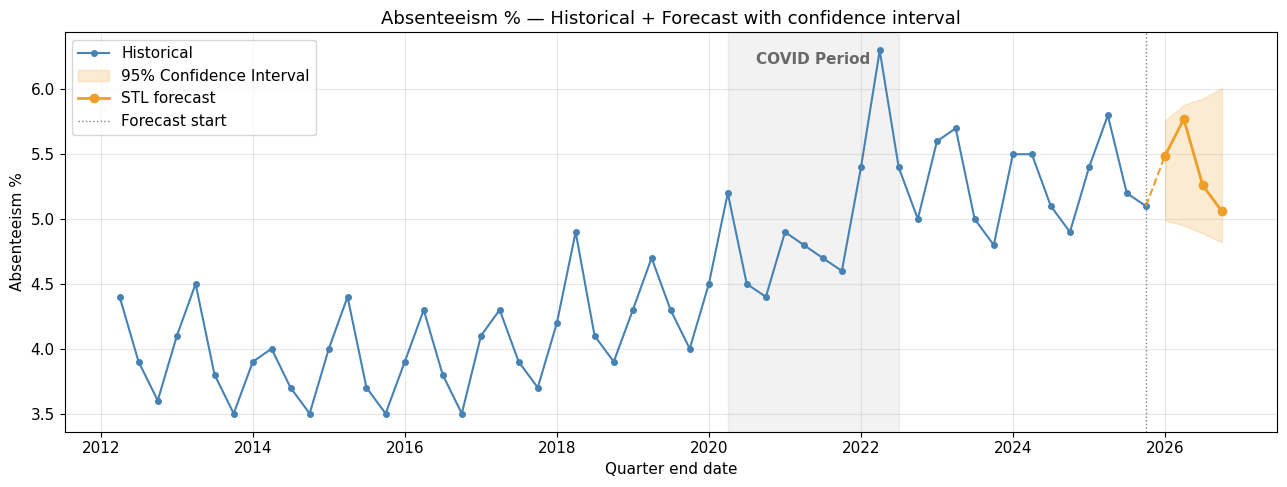

In [132]:
fig, ax = plt.subplots(figsize=(13, 5))

# 1. Historical series
ax.plot(df_ts.index, df_ts.values,
        marker="o", linewidth=1.5, markersize=4,
        color="steelblue", label="Historical")

# 2. Uncertainty Interval (Shaded Area)
ax.fill_between(df_forecast.index, 
                df_forecast["lower_95"], 
                df_forecast["upper_95"], 
                color="#EF9F27", alpha=0.2, label="95% Confidence Interval")

# 3. Bridge: connect last historical point to first forecast
bridge_dates = [df_ts.index[-1], df_forecast.index[0]]
bridge_vals  = [df_ts.iloc[-1],  df_forecast["forecast"].iloc[0]]
ax.plot(bridge_dates, bridge_vals,
        color="#EF9F27", linewidth=1.5, linestyle="--")

# 4. Forecast series
ax.plot(df_forecast.index, df_forecast["forecast"],
        marker="o", linewidth=2, markersize=6,
        color="#EF9F27", label="STL forecast")

# Vertical separator at forecast boundary
ax.axvline(df_ts.index[-1],
           color="gray", linestyle=":", linewidth=1,
           label="Forecast start")
# Vertical Band (COVID Period) 
ax.axvspan(covid_start, covid_end, color='grey', alpha=0.1)
ax.text(x=covid_start + (covid_end - covid_start) / 2, 
           y=0.95, 
           s='COVID Period', 
           color='dimgrey', 
           fontweight='bold',
           ha='center', 
           va='top', 
           transform=ax.get_xaxis_transform())
ax.set_title("Absenteeism % — Historical + Forecast with confidence interval", fontsize=13)
ax.set_ylabel("Absenteeism %")
ax.set_xlabel("Quarter end date")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

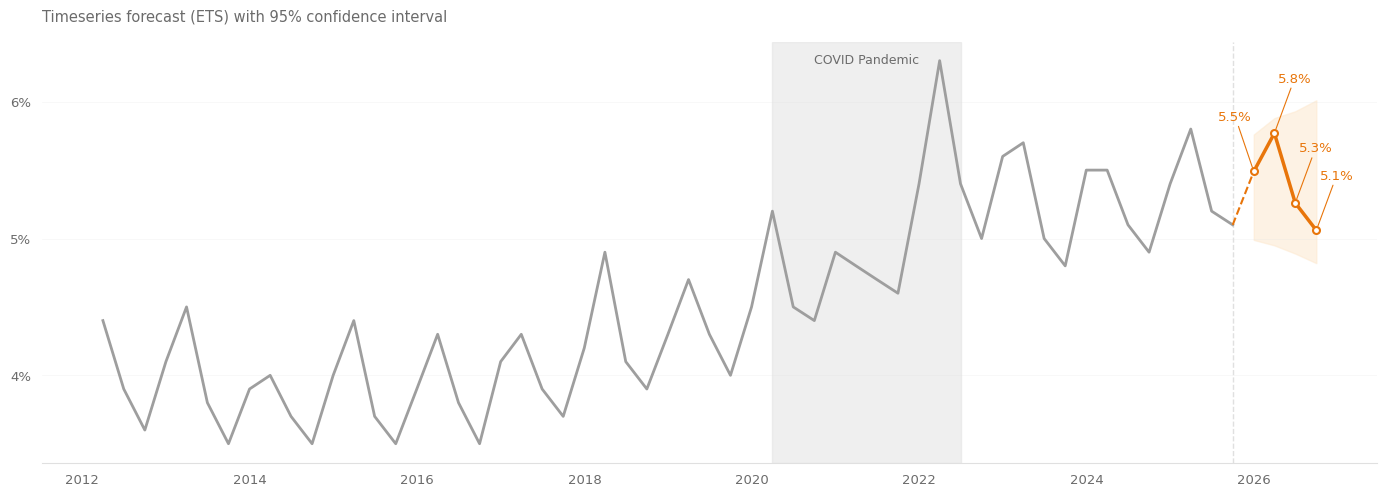

In [144]:
output_dir = Path("images")
output_dir.mkdir(exist_ok=True)

def plot_forecast_storytelling(df_ts, df_forecast, covid_start, covid_end):

    # --- Colour palette (matches structural breaks visual) ---
    GREY_LINE   = "#9E9E9E"
    GREY_LIGHT  = "#E0E0E0"
    ORANGE_MAIN = "#E8750A"
    ORANGE_FILL = "#FDEAD2"
    TEXT_DARK   = "#2D2D2D"
    TEXT_MID    = "#6B6B6B"

    fig, ax = plt.subplots(figsize=(14, 5.5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Remove spines except bottom
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(GREY_LIGHT)
    ax.spines["bottom"].set_linewidth(0.8)

    # --- COVID shading ---
    ax.axvspan(covid_start, covid_end, color=GREY_LIGHT, alpha=0.5, zorder=0)
    mid_covid = covid_start + (covid_end - covid_start) / 2
    ax.text(mid_covid, 0.97, "COVID Pandemic",
            color=TEXT_MID, fontsize=9, fontweight="medium",
            ha="center", va="top", transform=ax.get_xaxis_transform())

    # --- Confidence interval ---
    ax.fill_between(df_forecast.index,
                    df_forecast["lower_95"],
                    df_forecast["upper_95"],
                    color=ORANGE_FILL, alpha=0.6, zorder=1)

    # --- Historical series ---
    ax.plot(df_ts.index, df_ts.values,
            linewidth=2, color=GREY_LINE, zorder=2)

    # --- Bridge: connect last historical to first forecast ---
    bridge_dates = [df_ts.index[-1], df_forecast.index[0]]
    bridge_vals  = [df_ts.iloc[-1], df_forecast["forecast"].iloc[0]]
    ax.plot(bridge_dates, bridge_vals,
            color=ORANGE_MAIN, linewidth=1.5, linestyle="--", zorder=3)

    # --- Forecast series ---
    ax.plot(df_forecast.index, df_forecast["forecast"],
            linewidth=2.5, color=ORANGE_MAIN, zorder=4,
            marker="o", markersize=5, markerfacecolor="white",
            markeredgecolor=ORANGE_MAIN, markeredgewidth=1.5)

    # --- Forecast boundary ---
    ax.axvline(df_ts.index[-1], color=GREY_LIGHT, linestyle="--",
               linewidth=1, zorder=1)

    # --- Annotations on all forecast points ---
    for i, (dt, row) in enumerate(df_forecast.iterrows()):
        fc = row["forecast"]
        offset = pd.DateOffset(weeks=-1) if i == 0 else pd.DateOffset(weeks=2)
        ha = "right" if i == 0 else "left"
        ax.annotate(
            f"{fc:.1f}%",
            xy=(dt, fc),
            xytext=(dt + offset, fc + 0.35),
            fontsize=9.5, fontweight="medium", color=ORANGE_MAIN,
            ha=ha, va="bottom",
            arrowprops=dict(arrowstyle="-", color=ORANGE_MAIN,
                            lw=0.8, shrinkA=0, shrinkB=3),
        )

    # --- Axis formatting ---
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", colors=TEXT_MID, labelsize=9.5, length=0, pad=8)
    ax.tick_params(axis="y", colors=TEXT_MID, labelsize=9.5, length=0, pad=8)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f%%"))
    ax.grid(axis="y", color=GREY_LIGHT, linewidth=0.5, zorder=0)
    ax.grid(axis="x", visible=False)

    # --- Title (left-aligned, editorial) ---
#     ax.text(0.0, 1.12,
#             "Absenteeism forecast — All sectors",
#             transform=ax.transAxes, fontsize=16, fontweight="bold",
#             color=TEXT_DARK, ha="left", va="bottom")
    ax.text(0.0, 1.04,
            "Timeseries forecast (ETS) with 95% confidence interval",
            transform=ax.transAxes, fontsize=10.5,
            color=TEXT_MID, ha="left", va="bottom")

    plt.tight_layout()
    plt.subplots_adjust(top=0.84)
    plt.savefig(output_dir / "forecast_storytelling.png",
                dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()

plot_forecast_storytelling(df_ts, df_forecast, covid_start, covid_end)

In [160]:
# --- Build results DataFrame for plotting ---
# Using the index from df_ts to match the timing of the actuals evaluated
# We take the LAST 'len(actuals)' dates from the time series index
eval_dates = df_ts.index[-len(actuals):]

df_results = pd.DataFrame({
    "period_enddate": eval_dates,
    "actual":         actuals,
    "stl_prediction": stl_preds,
    "baseline":       baseline_preds
})

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 5))

# Actual values
ax.plot(df_results["period_enddate"], df_results["actual"],
        marker="o", linewidth=1.5, markersize=4, color="steelblue", linestyle="-", alpha=0.8, label="Actual")

# STL Prediction (Historical Evaluation)
ax.plot(df_results["period_enddate"], df_results["stl_prediction"],
        marker="o", linewidth=1.5, markersize=3, color="orange", label="STL Model (Historical)")
# Vertical Band (COVID Period) 
ax.axvspan(covid_start, covid_end, color='grey', alpha=0.1)
ax.text(x=covid_start + (covid_end - covid_start) / 2, 
           y=0.95, 
           s='COVID Period', 
           color='dimgrey', 
           fontweight='bold',
           ha='center', 
           va='top', 
           transform=ax.get_xaxis_transform())
# Baseline
ax.plot(df_results["period_enddate"], df_results["baseline"],
        marker="^", linewidth=1.5, markersize=2, color="grey", linestyle=":", alpha=0.5, label="Baseline (YoY)")

ax.set_title("Model Validation: STL vs Baseline (Historical Performance)", fontsize=13)
ax.set_ylabel("Absenteeism %")
ax.set_xlabel("Quarter End Date")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: All arrays must be of the same length

#### Different approach: AutoETS


In [145]:
CV_DIR = Path("cv_output")
 
# %% 1. Load CV results
df_cv = pd.read_parquet(CV_DIR / "autoets_cv_results.parquet")
df_cv["date"] = pd.to_datetime(df_cv["date"])
 
with open(CV_DIR / "autoets_best_configs.json") as f:
    configs = json.load(f)
 
df_corr = pd.read_parquet(CV_DIR / "autoets_corrected_series.parquet")
df_corr["period_enddate"] = pd.to_datetime(df_corr["period_enddate"])
 
print(f"Segments with results: {list(configs.keys())}")
for code, cfg in configs.items():
    print(f"\n  {code}:")
    for k, v in cfg.items():
        print(f"    {k}: {v}")

# --- Settings ---
n_forecast = 4      # Number of quarters to predict into the future
spec_label = "MNM"  # The specific ETS model type: Multiplicative Error, No Trend, Multiplicative Seasonality
season_length = 4   # Quarterly data has a seasonal cycle of 4
 
# --- Fit on full noncorrected series and forecast ---
# Statsforecast library. These models require a specific DataFrame format:
sf_df = pd.DataFrame({
    "unique_id": "T001081", # 'unique_id': A label for the series (StatsForecast can handle thousands of series at once)
    "ds": df_ts.index, # 'ds': The datestamp column
    "y": df_ts.values.ravel(), # 'y': The actual values (absenteeism %)
})
 
# Define the AutoETS model
# alias=spec_label: This renames the output column to "MNM" instead of a generic name
model = AutoETS(season_length=season_length, 
                model=spec_label, 
                damped=False,
                alias=spec_label)

# The 'StatsForecast' object acts as a wrapper/engine that runs the models
sf = StatsForecast(models=[model], freq="QE", n_jobs=1)

# h=n_forecast: The 'horizon' (how many steps to look ahead)
# level=[95]: Tells the model to calculate 95% confidence intervals (prediction intervals)
forecast_sf = sf.forecast(df=sf_df, h=n_forecast, level=[95])

# Convert 'ds' back to a proper datetime format (sometimes it returns as strings or periods)
forecast_sf["ds"] = pd.to_datetime(forecast_sf["ds"])
 
# --- Build output DataFrame ---
# StatsForecast outputs columns with specific names based on the model and the 'level'
# 'MNM' is the point forecast
# 'MNM-lo-95' is the lower boundary
# 'MNM-hi-95' is the upper boundary
df_forecast = pd.DataFrame({
    "forecast": forecast_sf[spec_label].values.round(2),
    "lower_95": forecast_sf[f"{spec_label}-lo-95"].values.round(2),
    "upper_95": forecast_sf[f"{spec_label}-hi-95"].values.round(2),
}, index=forecast_sf["ds"])
 
print("Forecasted absenteeism % (next 4 quarters):")
print(df_forecast)
 
# --- CV accuracy from saved results (if available) ---
df_cv = pd.read_parquet("cv_output/autoets_cv_results.parquet")
df_cv["date"] = pd.to_datetime(df_cv["date"])
try:
    outer = df_cv[(df_cv["sbi_code"] == "T001081") &
                  (df_cv["fold_set"] == "outer")].dropna(subset=["pred"])
    actuals = outer["actual"].values
    preds   = outer["pred"].values
    errors  = preds - actuals
 
    mae_ets  = np.mean(np.abs(errors))
    rmse_ets = np.sqrt(np.mean(errors**2))
    mape_ets = np.mean(np.abs(errors / actuals)) * 100

    # --- Advanced Diagnostics ---
    me_ets = np.mean(errors)
    max_ae = np.max(np.abs(errors))

    # Directional Accuracy (Sign Test)
    actual_diff = np.diff(actuals)
    pred_diff = np.diff(preds)
    directional_hit = np.mean(np.sign(actual_diff) == np.sign(pred_diff)) * 100

    print(f"  Bias (Mean Error): {me_ets:.3f} ({'Overestimating' if me_ets > 0 else 'Underestimating'})")
    print(f"  Worst-Case Error (Max Error):  {max_ae:.3f}")
    print(f"  Directional Accuracy: {directional_hit:.1f}%")

    
    print(f"\nModel accuracy on historical data (walk-forward, {len(actuals)} quarters):")
    print(f"  MAE:  {mae_ets:.3f}")
    print(f"  RMSE: {rmse_ets:.3f}")
    print(f"  MAPE: {mape_ets:.1f}%")
except Exception:
    print("\n  (CV results not loaded — run analyze_ets_results.py first)")

print(f"  MAE baseline: {mae_baseline:.3f}")
print(f"  ETS forecast vs baseline: {(mae_baseline - mae_ets) / mae_baseline * 100:.1f}% improvement")

Segments with results: ['300003', '300007', '300013', '301000', '305700', '307500', '307610', '317105', '320005', '328110', '346600', '348000', '350000', '354200', '354300', '356900', '371600', '383100', '383200', '389100', '391600', '396300', '402000', '403300', '410200', '415300', '417400', '419000', '422400', '422500', '422600', '425300', '426600', '428100', '435500', 'T001081', 'WP19078', 'WP19091', 'WP19098']

  300003:
    winning_correction: no_correction
    correction_is_winsorized: False
    best_model_spec: MAM
    inner_mae: 0.2316487423453854
    outer_mae: 0.18204284000390464
    inner_outer_ratio: 1.272495761659271
    n_inner_folds: 18
    n_outer_folds: 13
    n_configs_searched: 54

  300007:
    winning_correction: no_correction
    correction_is_winsorized: False
    best_model_spec: MAM
    inner_mae: 0.1752629569201781
    outer_mae: 0.1327213011077689
    inner_outer_ratio: 1.32053374595737
    n_inner_folds: 18
    n_outer_folds: 13
    n_configs_searched: 54

 

In [151]:
"""
Per-sector forecast diagnostics
================================
Assumes already loaded:
  - df_cv              : AutoETS walk-forward CV results (all sectors)
  - df_baseline_total  : baseline predictions (all sectors)
  - configs            : best config dict from autoets_best_configs.json
"""
# =====================================================================
# LOOP OVER ALL SECTORS
# =====================================================================
query = """ SELECT * FROM prediction_baseline_total
            UNION ALL
            SELECT * FROM prediction_baseline_sbi
            UNION ALL
            SELECT * FROM prediction_baseline_compsize"""
df_baseline_all = f_query_database(DIR_DB_GOLD, query, "pandas")
df_baseline_all["period_enddate"] = pd.to_datetime(df_baseline_all["period_enddate"])

sbi_codes = sorted(set(df_cv["sbi_code"].unique()) & set(df_baseline_all["sbi_code"].unique()))
sbi_titles = (
    df_baseline_all.drop_duplicates("sbi_code")
    .set_index("sbi_code")["sbi_title"]
    .to_dict()
)
summary_rows = []

n_skipped = len(set(df_cv["sbi_code"].unique()) - set(sbi_codes))
print(f"  Sectors with baseline: {len(sbi_codes)} | Skipped (no baseline): {n_skipped}")

print("=" * 80)
print("  PER-SECTOR FORECAST DIAGNOSTICS")
print("=" * 80)

for code in sbi_codes:

    # --- ETS outer-fold results ---
    outer = df_cv[
        (df_cv["sbi_code"] == code) &
        (df_cv["fold_set"] == "outer")
    ].dropna(subset=["pred"])

    if len(outer) < 3:
        print(f"\n  {code}: insufficient outer folds ({len(outer)}), skipping.")
        continue

    actuals = outer["actual"].values
    preds   = outer["pred"].values
    errors  = preds - actuals

    mae_ets  = np.mean(np.abs(errors))
    rmse_ets = np.sqrt(np.mean(errors**2))
    mape_ets = np.mean(np.abs(errors / actuals)) * 100
    me_ets   = np.mean(errors)
    max_ae   = np.max(np.abs(errors))

    # Directional accuracy
    actual_diff = np.diff(actuals)
    pred_diff   = np.diff(preds)
    dir_acc = (np.mean(np.sign(actual_diff) == np.sign(pred_diff)) * 100
               if len(actual_diff) > 0 else np.nan)

    # --- Baseline MAE for this sector ---
    outer_dates = set(pd.to_datetime(outer["date"]))
    bl_sector = df_baseline_all[
        df_baseline_all["sbi_code"] == code
    ].copy()
    bl_sector["period_enddate"] = pd.to_datetime(bl_sector["period_enddate"])
    bl_matched = bl_sector[bl_sector["period_enddate"].isin(outer_dates)]

    if len(bl_matched) > 0:
        bl_merged = (
            outer[["date", "actual"]]
            .merge(
                bl_matched[["period_enddate", "baseline_prediction"]],
                left_on="date", right_on="period_enddate", how="inner"
            )
        )
        mae_baseline = float(np.mean(np.abs(
            bl_merged["actual"].values - bl_merged["baseline_prediction"].values
        )))
        improvement = (mae_baseline - mae_ets) / mae_baseline * 100
    else:
        mae_baseline = np.nan
        improvement = np.nan

    # --- Config info ---
    cfg = configs.get(code, {})
    spec = cfg.get("best_model_spec", "?")
    correction = cfg.get("winning_correction", "?")

    # --- Print ---
    title = sbi_titles.get(code, "")
    print(f"\n{'—' * 80}")
    print(f"  {code}  |  {title}")
    print(f"  {spec}  |  {correction}")
    print(f"{'—' * 80}")
    print(f"  Walk-forward evaluation ({len(actuals)} outer quarters):")
    print(f"    MAE:  {mae_ets:.3f}    RMSE: {rmse_ets:.3f}    MAPE: {mape_ets:.1f}%")
    print(f"    Bias: {me_ets:+.3f} ({'overestimating' if me_ets > 0 else 'underestimating'})")
    print(f"    Max error:            {max_ae:.3f}")
    print(f"    Directional accuracy: {dir_acc:.1f}%")

    if np.isfinite(mae_baseline):
        print(f"    Baseline MAE:         {mae_baseline:.3f}")
        print(f"    Improvement vs base:  {improvement:+.1f}%")
    else:
        print(f"    Baseline MAE:         n/a (no matching dates)")

    # --- Collect for summary ---
    summary_rows.append({
        "sbi_code":       code,
        "sbi_title":      title,
        "spec":           spec,
        "n_outer":        len(actuals),
        "mae":            mae_ets,
        "rmse":           rmse_ets,
        "mape":           mape_ets,
        "bias":           me_ets,
        "max_error":      max_ae,
        "dir_accuracy":   dir_acc,
        "mae_baseline":   mae_baseline,
        "improvement_pct": improvement,
    })


# =====================================================================
# SUMMARY TABLE
# =====================================================================

df_summary = pd.DataFrame(summary_rows).sort_values("mae")

print(f"\n\n{'=' * 130}")
print("  SUMMARY TABLE (sorted by MAE)")
print(f"{'=' * 130}")
print(f"  {'Code':<12s} {'Sector':<35s} {'Spec':<6s} {'n':>3s} {'MAE':>7s} {'RMSE':>7s} "
      f"{'MAPE%':>7s} {'Bias':>7s} {'MaxErr':>7s} {'DirAcc':>7s} "
      f"{'BL MAE':>7s} {'Impr%':>7s}")
print(f"  {'-' * 125}")

for _, row in df_summary.iterrows():
    bl_str = f"{row['mae_baseline']:.3f}" if np.isfinite(row['mae_baseline']) else "   n/a"
    imp_str = f"{row['improvement_pct']:+.1f}" if np.isfinite(row['improvement_pct']) else "   n/a"
    title_short = (row['sbi_title'][:33] + "..") if len(str(row['sbi_title'])) > 35 else str(row['sbi_title'])
    print(f"  {row['sbi_code']:<12s} {title_short:<35s} {row['spec']:<6s} {row['n_outer']:>3.0f} "
          f"{row['mae']:>7.3f} {row['rmse']:>7.3f} {row['mape']:>6.1f}% "
          f"{row['bias']:>+7.3f} {row['max_error']:>7.3f} {row['dir_accuracy']:>6.1f}% "
          f"{bl_str:>7s} {imp_str:>7s}")

# =====================================================================
# AGGREGATE STATS
# =====================================================================

print(f"\n{'=' * 100}")
print("  AGGREGATE")
print(f"{'=' * 100}")

n_sectors = len(df_summary)
n_beating_baseline = df_summary[df_summary["improvement_pct"] > 0].shape[0]
n_with_baseline = df_summary["improvement_pct"].notna().sum()

print(f"  Sectors evaluated:          {n_sectors}")
print(f"  Beating baseline:           {n_beating_baseline}/{n_with_baseline}")
print(f"  Median MAE:                 {df_summary['mae'].median():.3f}")
print(f"  Median MAPE:                {df_summary['mape'].median():.1f}%")
print(f"  Median directional acc:     {df_summary['dir_accuracy'].median():.1f}%")
print(f"  Median improvement vs base: {df_summary['improvement_pct'].median():.1f}%")

# Worst performers
print(f"\n  Worst 5 by MAE:")
for _, row in df_summary.tail(5).iterrows():
    print(f"    {row['sbi_code']:<12s} MAE={row['mae']:.3f}  MaxErr={row['max_error']:.3f}")

print(f"\n{'=' * 100}")

  Sectors with baseline: 23 | Skipped (no baseline): 16
  PER-SECTOR FORECAST DIAGNOSTICS

————————————————————————————————————————————————————————————————————————————————
  301000  |  A Landbouw, bosbouw en visserij
  MNN  |  no_correction
————————————————————————————————————————————————————————————————————————————————
  Walk-forward evaluation (13 outer quarters):
    MAE:  0.254    RMSE: 0.366    MAPE: 7.6%
    Bias: +0.089 (overestimating)
    Max error:            1.001
    Directional accuracy: 0.0%
    Baseline MAE:         0.231
    Improvement vs base:  -10.0%

————————————————————————————————————————————————————————————————————————————————
  305700  |  B Delfstoffenwinning
  MAdM  |  no_correction|winsorized
————————————————————————————————————————————————————————————————————————————————
  Walk-forward evaluation (13 outer quarters):
    MAE:  0.221    RMSE: 0.290    MAPE: 4.6%
    Bias: -0.077 (underestimating)
    Max error:            0.616
    Directional accuracy: 83.3%


In [153]:
"""
Sector Tiering by Forecast Quality
===================================
Assumes already loaded:
    configs            : best config dict from autoets_best_configs.json
    df_baseline_all  : baseline predictions (contains sbi_title)

Threshold logic:
    - GOOD  (outer MAE < 0.20): ~4% relative error on typical absenteeism
      of 5%. Forecast is tight enough to drive operational decisions
      (staffing, budgeting) with confidence.
    - ACCEPTABLE (0.20 ≤ MAE < 0.30): ~4-6% relative error. Useful for
      directional planning but uncertainty should be communicated.
      Still competitive with or better than the baseline (~0.30).
    - POOR (MAE ≥ 0.30): At or above baseline-level accuracy. The model
      isn't demonstrably better than a 3-year seasonal average for these
      sectors. Forecasts should carry explicit uncertainty warnings or
      be replaced with simpler methods.
"""

import pandas as pd

# =====================================================================
# 1. BUILD TIERING TABLE
# =====================================================================

TIER_GOOD_THRESHOLD = 0.20       # outer MAE below this = good
TIER_POOR_THRESHOLD = 0.30       # outer MAE at or above this = poor

sbi_titles = (
    df_baseline_all.drop_duplicates("sbi_code")
    .set_index("sbi_code")["sbi_title"]
    .to_dict()
)

bl_available_codes = set(df_baseline_all["sbi_code"].unique())

records = []
n_skipped = 0
for code, cfg in configs.items():
    if code not in bl_available_codes:
        n_skipped += 1
        continue

    outer_mae = cfg["outer_mae"]

    if outer_mae < TIER_GOOD_THRESHOLD:
        tier = "1_GOOD"
    elif outer_mae < TIER_POOR_THRESHOLD:
        tier = "2_ACCEPTABLE"
    else:
        tier = "3_POOR"

    records.append({
        "sbi_code":        code,
        "sbi_title":       sbi_titles.get(code, ""),
        "tier":            tier,
        "outer_mae":       outer_mae,
        "inner_mae":       cfg["inner_mae"],
        "inner_outer_ratio": cfg.get("inner_outer_ratio"),
        "model_spec":      cfg["best_model_spec"],
        "correction":      cfg["winning_correction"],
        "struct_warn":     cfg.get("structural_break_warning"),
        "seasonal_warn":   cfg.get("seasonal_shift_warning"),
    })

df_tiers = (
    pd.DataFrame(records)
    .sort_values(["tier", "outer_mae"])
    .reset_index(drop=True)
)

# =====================================================================
# 2. SUMMARY
# =====================================================================

print("=" * 90)
print("  SECTOR TIERING SUMMARY")
if n_skipped > 0:
    print(f"  ({n_skipped} sectors skipped — no baseline available)")
print("=" * 90)

tier_counts = df_tiers["tier"].value_counts().sort_index()
for tier, count in tier_counts.items():
    tier_subset = df_tiers[df_tiers["tier"] == tier]
    avg_mae = tier_subset["outer_mae"].mean()
    label = tier.split("_", 1)[1]
    print(f"\n  {label} ({count} sectors, avg outer MAE: {avg_mae:.3f}):")

    for _, row in tier_subset.iterrows():
        flags = []
        if row["struct_warn"]:
            flags.append("BREAK")
        if row["seasonal_warn"]:
            flags.append("SEASON")
        ratio = row["inner_outer_ratio"]
        if ratio and ratio < 0.90:
            flags.append(f"DEGRADING(ratio={ratio:.2f})")
        flag_str = f"  ⚠ {', '.join(flags)}" if flags else ""

        title_short = (row["sbi_title"][:30] + "..") if len(str(row["sbi_title"])) > 32 else str(row["sbi_title"])
        print(f"    {row['sbi_code']:<12s} {title_short:<33s} MAE={row['outer_mae']:.3f}  "
              f"{row['model_spec']:<6s}{flag_str}")

# =====================================================================
# 3. RISK FLAGS
# =====================================================================

print("\n\n" + "=" * 90)
print("  SECTORS REQUIRING ATTENTION")
print("=" * 90)

# Poor tier
poor = df_tiers[df_tiers["tier"] == "3_POOR"]
if len(poor) > 0:
    print(f"\n  POOR TIER ({len(poor)} sectors):")
    print("  These sectors are at or below baseline accuracy.")
    print("  Consider: simpler model, exogenous variables, or explicit")
    print("  low-confidence flagging on forecasts.")
    for _, row in poor.iterrows():
        print(f"    {row['sbi_code']:<12s} {row['sbi_title']:<40s} MAE={row['outer_mae']:.3f}")

# Degrading (ratio < 0.90 in any tier)
degrading = df_tiers[
    df_tiers["inner_outer_ratio"].notna() &
    (df_tiers["inner_outer_ratio"] < 0.90)
]
if len(degrading) > 0:
    print(f"\n  DEGRADING PERFORMANCE ({len(degrading)} sectors):")
    print("  Outer MAE is worse than inner MAE — model accuracy is")
    print("  declining on recent data regardless of tier.")
    for _, row in degrading.iterrows():
        print(f"    {row['sbi_code']:<12s} {row['sbi_title']:<40s} "
              f"MAE={row['outer_mae']:.3f}  ratio={row['inner_outer_ratio']:.2f}  "
              f"tier={row['tier']}")

# Structural breaks
breaks = df_tiers[df_tiers["struct_warn"].notna()]
if len(breaks) > 0:
    print(f"\n  STRUCTURAL BREAKS ({len(breaks)} sectors):")
    for _, row in breaks.iterrows():
        print(f"    {row['sbi_code']:<12s} {row['sbi_title']:<40s} {row['struct_warn']}")

# =====================================================================
# 4. STORE FOR DOWNSTREAM USE
# =====================================================================

# df_tiers is ready for joining with forecasts, reports, etc.
print(f"\n\n  df_tiers shape: {df_tiers.shape}")
print(f"  Columns: {list(df_tiers.columns)}")
print("\n" + "=" * 90)

  SECTOR TIERING SUMMARY
  (16 sectors skipped — no baseline available)

  GOOD (14 sectors, avg outer MAE: 0.164):
    WP19091      10 tot 100 werkzame personen      MAE=0.125  MAM   
    350000       F Bouwnijverheid                  MAE=0.146  MNM   
    T001081      A-U Alle economische activitei..  MAE=0.152  MNM   
    391600       J Informatie en communicatie      MAE=0.152  MAM   
    307500       C Industrie                       MAE=0.155  MAA   
    428100       R Cultuur, sport en recreatie     MAE=0.160  MNA   
    403300       M Specialistische zakelijke di..  MAE=0.161  MAdA  
    WP19098      100 of meer werkzame personen     MAE=0.162  MAM   
    402000       L Verhuur en handel van onroer..  MAE=0.163  MNA   
    383100       H Vervoer en opslag               MAE=0.178  MAM   
    417400       O Openbaar bestuur en overheid..  MAE=0.180  MAdM  
    354200       G Handel                          MAE=0.182  MAM   
    419000       P Onderwijs                       MAE=0

In [ ]:
"""
Per-Sector Forecast Plots — Grouped by Tier
=============================================
Assumes already loaded:
  - configs            : best config dict from autoets_best_configs.json
  - df_corr            : corrected series parquet (period_enddate, absenteeism_perc, sbi_code)
  - df_baseline_total  : baseline predictions (sbi_code, sbi_title, period_enddate, baseline_prediction)
  - df_tiers           : tiering DataFrame from sector_tiering.py
  - df_org / df_modified : original data with all sbi_codes

Also requires:
  - statsforecast, matplotlib
"""
# =====================================================================
# SETTINGS
# =====================================================================

n_forecast    = 4
season_length = 4
covid_start   = pd.Timestamp("2020-03-31")
covid_end     = pd.Timestamp("2022-06-30")

bl_available_codes = set(df_baseline_total["sbi_code"].unique())
sbi_titles = (
    df_baseline_total.drop_duplicates("sbi_code")
    .set_index("sbi_code")["sbi_title"]
    .to_dict()
)

# =====================================================================
# HELPER: Build historical series for a given sbi_code
# =====================================================================

def get_historical_series(sbi_code, df_modified):
    """Build a clean quarterly time series for one sector."""
    sub = (
        df_modified[df_modified["sbi_code"] == sbi_code]
        .copy()
        .sort_values("period_enddate")
        .reset_index(drop=True)
    )
    ts = (
        sub.set_index("period_enddate")["absenteeism_perc"]
        .asfreq("QE")
    )
    return ts


# =====================================================================
# HELPER: Generate forecast for one sector
# =====================================================================

def generate_forecast(sbi_code, df_ts, configs, df_corr):
    """
    Fit the winning ETS spec on the corrected series and forecast.
    Returns df_forecast with columns: forecast, lower_95, upper_95.
    """
    cfg = configs[sbi_code]
    spec_label = cfg["best_model_spec"]
    damped = "Ad" in spec_label  # MAdM, MAdA, MAdN → damped=True

    # Use corrected series if available, otherwise raw
    corr_sector = df_corr[df_corr["sbi_code"] == sbi_code]
    if len(corr_sector) > 0:
        ts_fit = (
            corr_sector
            .sort_values("period_enddate")
            .set_index("period_enddate")["absenteeism_perc"]
            .asfreq("QE")
        )
    else:
        ts_fit = df_ts

    # Apply winsorization if the winning config used it
    if cfg.get("correction_is_winsorized", False):
        lo = ts_fit.quantile(0.05)
        hi = ts_fit.quantile(0.95)
        ts_fit = ts_fit.clip(lower=lo, upper=hi)

    # StatsForecast format
    sf_df = pd.DataFrame({
        "unique_id": sbi_code,
        "ds": ts_fit.index,
        "y": ts_fit.values.ravel(),
    })

    # Map spec_label to model_str (strip "d" for damped variants)
    # MAdM → MAM damped, MAdA → MAA damped, MAdN → MAN damped
    if damped:
        model_str = spec_label.replace("Ad", "A")
    else:
        model_str = spec_label

    model = AutoETS(
        season_length=season_length,
        model=model_str,
        damped=damped,
        alias=spec_label,
    )
    sf = StatsForecast(models=[model], freq="QE", n_jobs=1)

    try:
        forecast_sf = sf.forecast(df=sf_df, h=n_forecast, level=[95])
        forecast_sf["ds"] = pd.to_datetime(forecast_sf["ds"])

        df_forecast = pd.DataFrame({
            "forecast": forecast_sf[spec_label].values.round(2),
            "lower_95": forecast_sf[f"{spec_label}-lo-95"].values.round(2),
            "upper_95": forecast_sf[f"{spec_label}-hi-95"].values.round(2),
        }, index=forecast_sf["ds"])

        return df_forecast
    except Exception as e:
        print(f"    ⚠️  Forecast failed for {sbi_code}: {e}")
        return None


# =====================================================================
# PLOT FUNCTION
# =====================================================================

def plot_sector(ax, sbi_code, df_ts, df_forecast, cfg, title_str):
    """Plot historical series + forecast + COVID shading on a given axis."""

    spec_label = cfg["best_model_spec"]

    # Historical
    ax.plot(df_ts.index, df_ts.values,
            marker="o", linewidth=1.5, markersize=3,
            color="steelblue", label="Historical")

    if df_forecast is not None:
        # Confidence interval
        ax.fill_between(df_forecast.index,
                        df_forecast["lower_95"],
                        df_forecast["upper_95"],
                        color="#EF9F27", alpha=0.2, label="95% CI")

        # Bridge
        bridge_dates = [df_ts.index[-1], df_forecast.index[0]]
        bridge_vals  = [df_ts.iloc[-1], df_forecast["forecast"].iloc[0]]
        ax.plot(bridge_dates, bridge_vals,
                color="#EF9F27", linewidth=1.5, linestyle="--")

        # Forecast
        ax.plot(df_forecast.index, df_forecast["forecast"],
                marker="o", linewidth=2, markersize=5,
                color="#EF9F27", label=f"ETS({spec_label})")

        # Forecast boundary
        ax.axvline(df_ts.index[-1],
                   color="gray", linestyle=":", linewidth=1)

    # COVID shading
    ax.axvspan(covid_start, covid_end, color="grey", alpha=0.08)
    ax.text(x=covid_start + (covid_end - covid_start) / 2,
            y=0.95, s="COVID", color="dimgrey", fontsize=7,
            ha="center", va="top", transform=ax.get_xaxis_transform())

    ax.set_title(title_str, fontsize=10)
    ax.set_ylabel("Absenteeism %", fontsize=8)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)


# =====================================================================
# MAIN: LOOP PER TIER AND PLOT
# =====================================================================

tiers_ordered = ["1_GOOD", "2_ACCEPTABLE", "3_POOR"]

for tier in tiers_ordered:
    tier_subset = df_tiers[df_tiers["tier"] == tier].copy()

    if len(tier_subset) == 0:
        continue

    tier_label = tier.split("_", 1)[1]
    n_sectors = len(tier_subset)

    # Grid layout: 2 columns
    n_cols = 2
    n_rows = int(np.ceil(n_sectors / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    fig.suptitle(f"Tier: {tier_label} ({n_sectors} sectors)",
                 fontsize=14, fontweight="bold", y=1.01)

    # Flatten axes for easy iteration
    if n_sectors == 1:
        axes = np.array([axes]).flatten()
    else:
        axes = axes.flatten()

    for i, (_, row) in enumerate(tier_subset.iterrows()):
        code = row["sbi_code"]
        title = sbi_titles.get(code, "")
        cfg = configs.get(code, {})
        mae_str = f"MAE={row['outer_mae']:.3f}"

        print(f"  Plotting {code} ({title[:40]})...")

        # Build historical series
        df_ts = get_historical_series(code, df_modified)

        # Generate forecast
        df_forecast = generate_forecast(code, df_ts, configs, df_corr)

        # Plot
        title_str = f"{code} — {title[:35]}\n{cfg.get('best_model_spec', '?')} | {mae_str}"
        plot_sector(axes[i], code, df_ts, df_forecast, cfg, title_str)

    # Hide unused subplots
    for j in range(n_sectors, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

print("\n✅ All tiers plotted.")

  Plotting WP19091 (10 tot 100 werkzame personen)...
  Plotting 350000 (F Bouwnijverheid)...
  Plotting T001081 (A-U Alle economische activiteiten)...
  Plotting 391600 (J Informatie en communicatie)...
  Plotting 307500 (C Industrie)...
  Plotting 428100 (R Cultuur, sport en recreatie)...
  Plotting 403300 (M Specialistische zakelijke diensten)...
  Plotting WP19098 (100 of meer werkzame personen)...
  Plotting 402000 (L Verhuur en handel van onroerend goed)...
  Plotting 383100 (H Vervoer en opslag)...
  Plotting 417400 (O Openbaar bestuur en overheidsdiensten)...
  Plotting 354200 (G Handel)...
  Plotting 419000 (P Onderwijs)...
  Plotting 346600 (D Energievoorziening)...


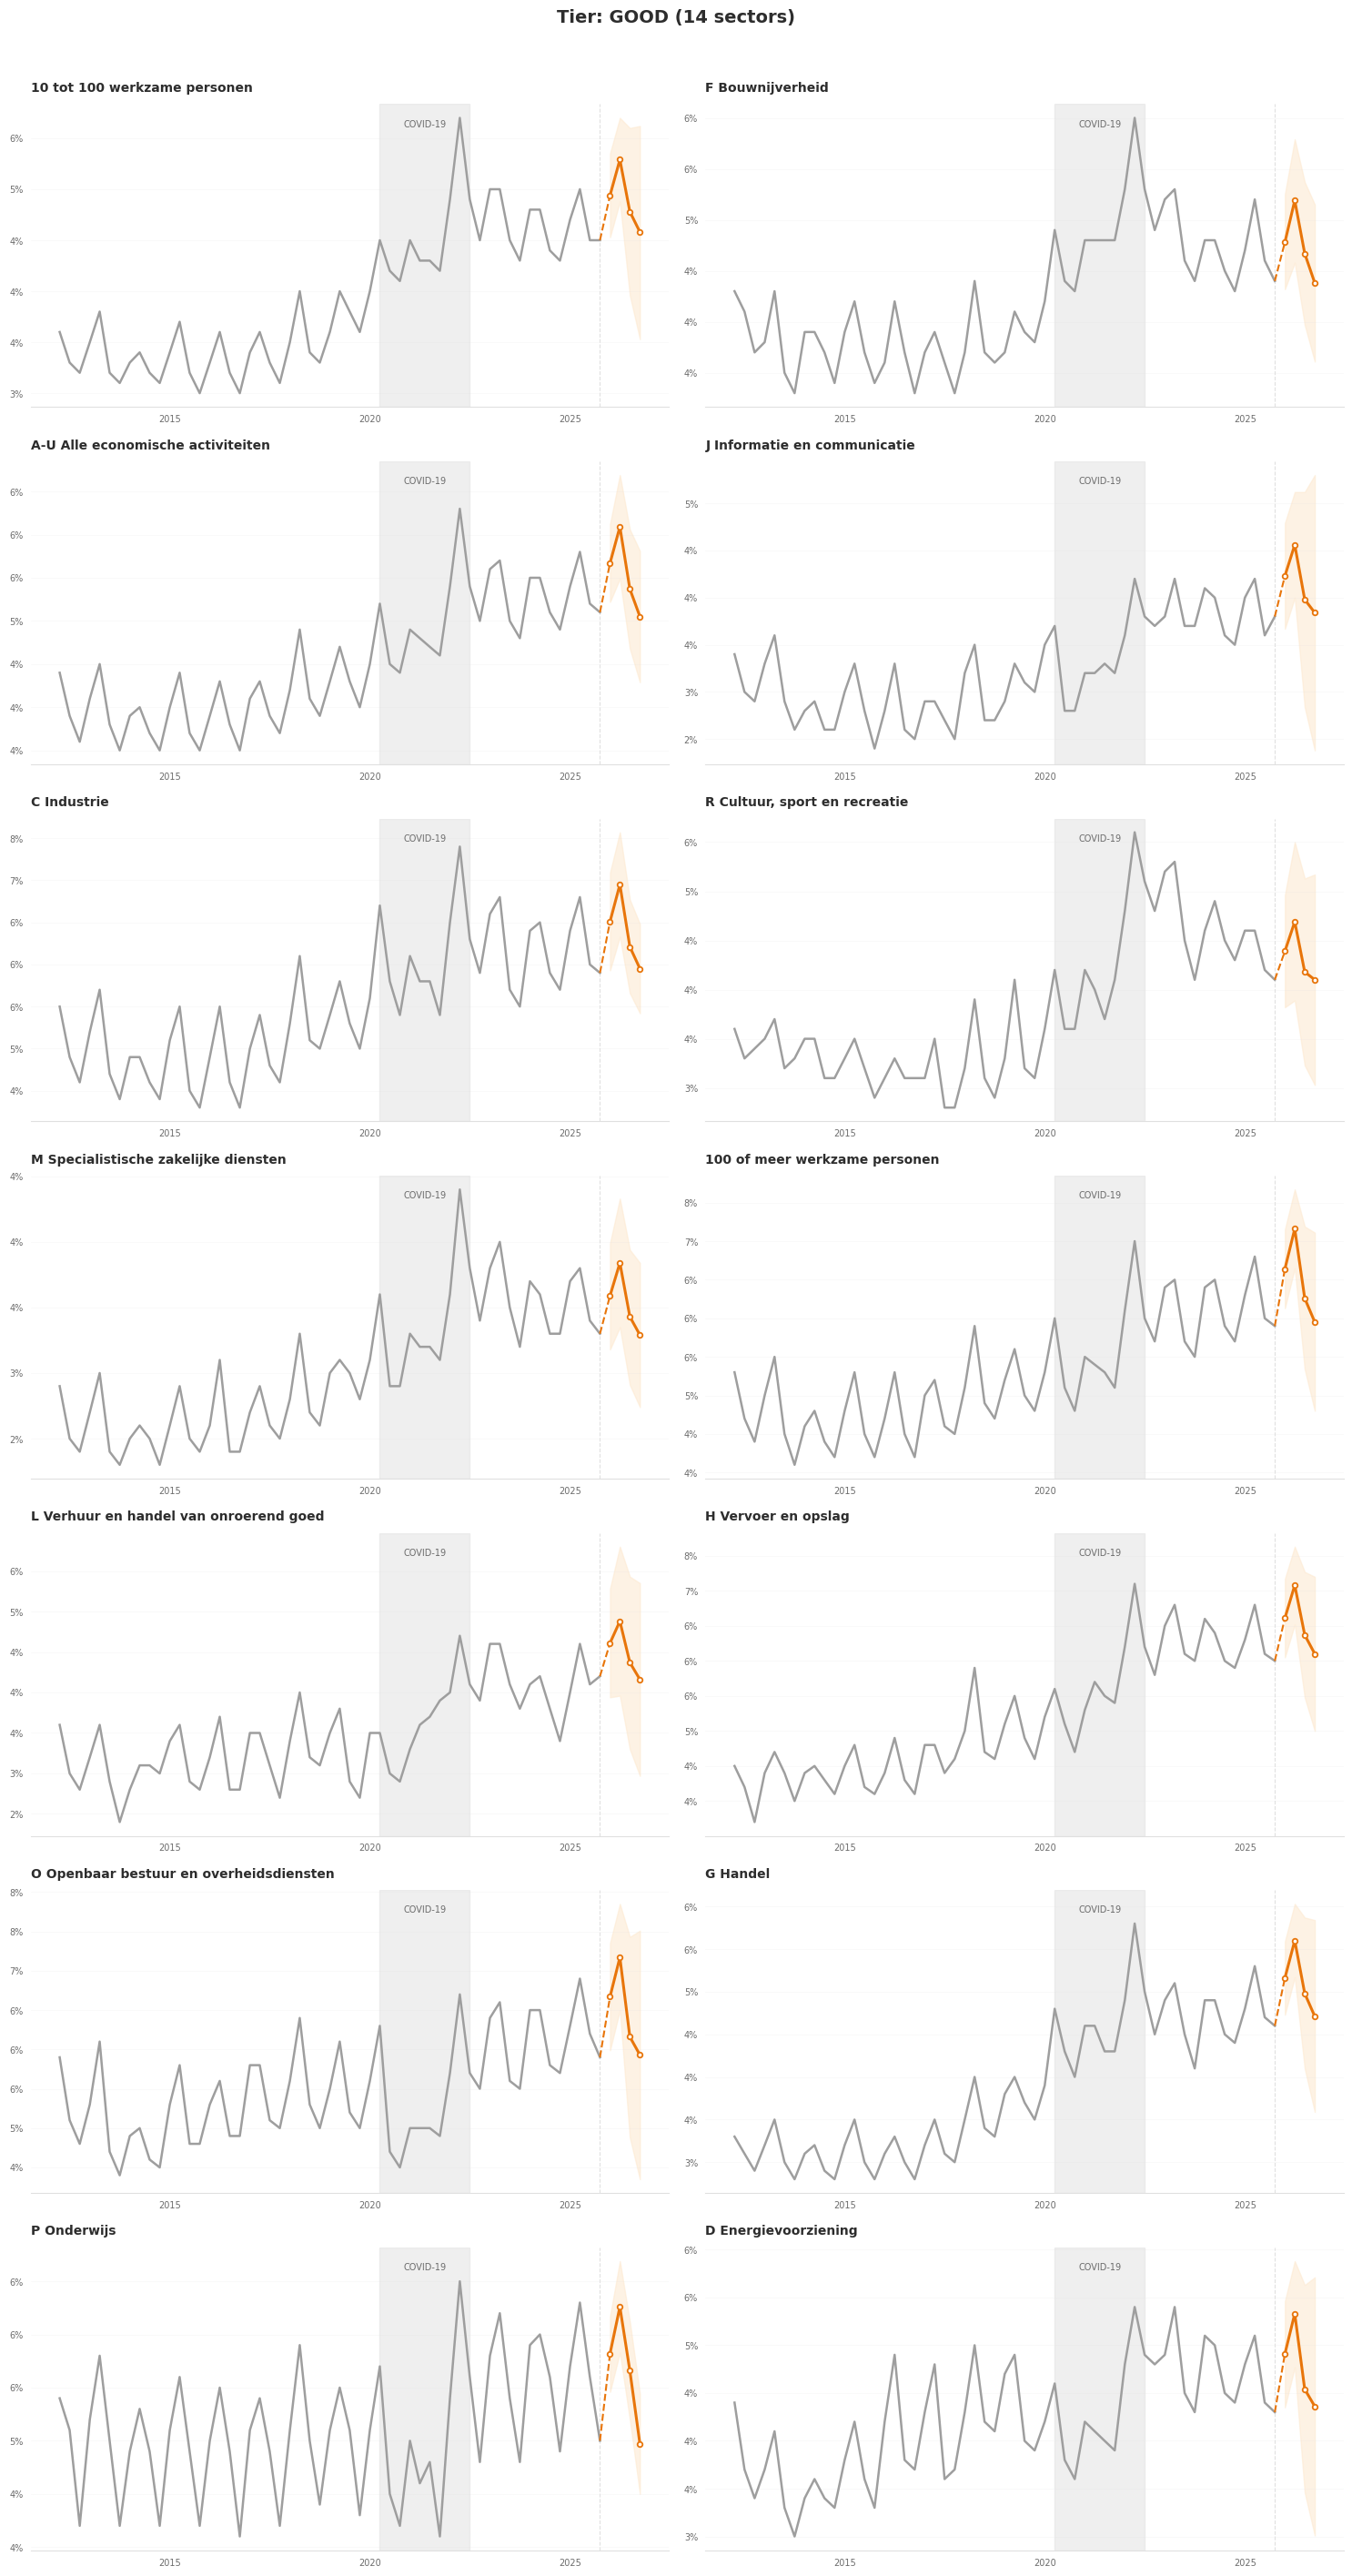

  Plotting 410200 (N Verhuur en overige zakelijke diensten)...
  Plotting 305700 (B Delfstoffenwinning)...
  Plotting WP19078 (1 tot 10 werkzame personen)...
  Plotting 422400 (Q Gezondheids- en welzijnszorg)...
  Plotting 301000 (A Landbouw, bosbouw en visserij)...
  Plotting 389100 (I Horeca)...


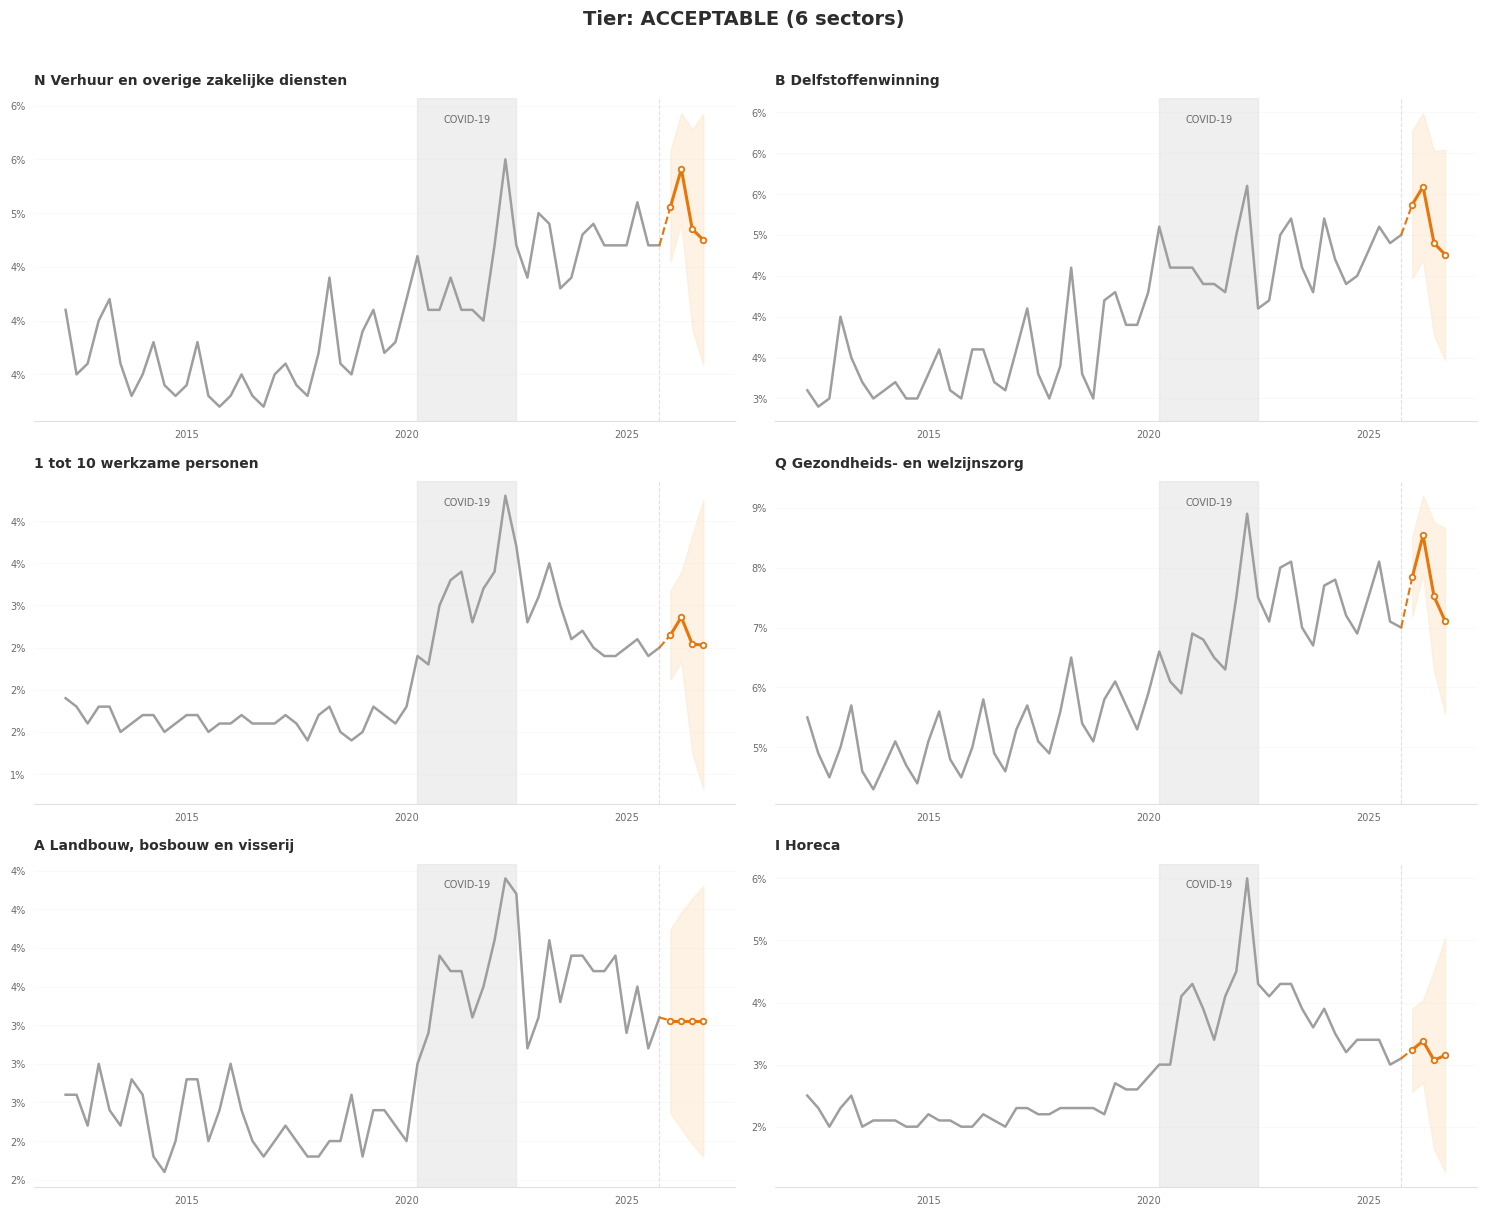

  Plotting 348000 (E Waterbedrijven en afvalbeheer)...
  Plotting 396300 (K Financiële dienstverlening)...
  Plotting 435500 (S Overige dienstverlening)...


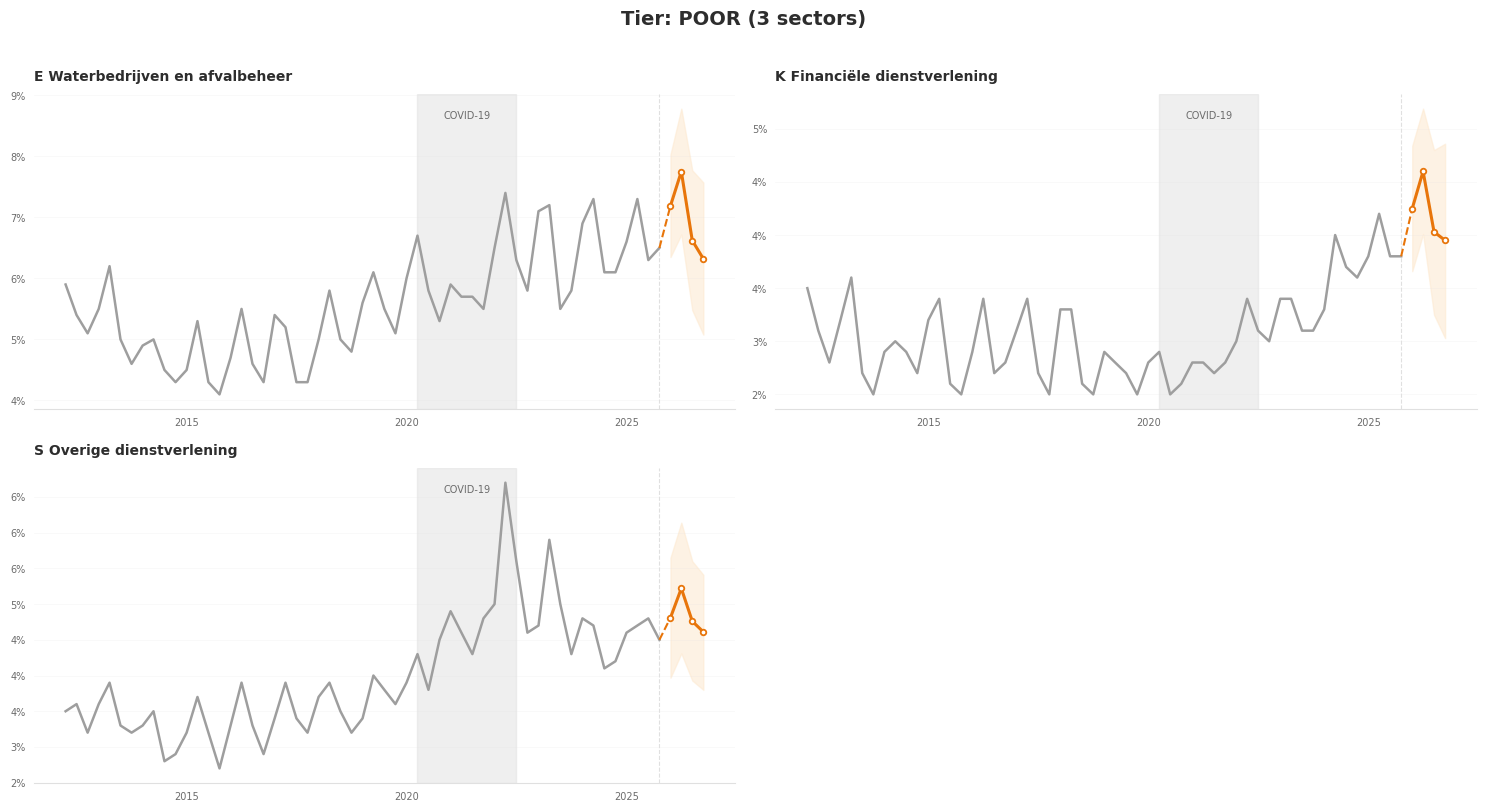


✅ All tiers plotted.


In [159]:
"""
Per-Sector Forecast Plots — Grouped by Tier
=============================================
Assumes already loaded:
  - configs            : best config dict from autoets_best_configs.json
  - df_corr            : corrected series parquet (period_enddate, absenteeism_perc, sbi_code)
  - df_baseline_all  : baseline predictions (sbi_code, sbi_title, period_enddate, baseline_prediction)
  - df_tiers           : tiering DataFrame from sector_tiering.py
  - df_org / df_modified : original data with all sbi_codes

Also requires:
  - statsforecast, matplotlib
"""
# =====================================================================
# SETTINGS
# =====================================================================

n_forecast    = 4
season_length = 4
covid_start   = pd.Timestamp("2020-03-31")
covid_end     = pd.Timestamp("2022-06-30")

bl_available_codes = set(df_baseline_all["sbi_code"].unique())
sbi_titles = (
    df_baseline_all.drop_duplicates("sbi_code")
    .set_index("sbi_code")["sbi_title"]
    .to_dict()
)

# =====================================================================
# HELPER: Build historical series for a given sbi_code
# =====================================================================

def get_historical_series(sbi_code, df_modified):
    """Build a clean quarterly time series for one sector."""
    sub = (
        df_modified[df_modified["sbi_code"] == sbi_code]
        .copy()
        .sort_values("period_enddate")
        .reset_index(drop=True)
    )
    ts = (
        sub.set_index("period_enddate")["absenteeism_perc"]
        .asfreq("QE")
    )
    return ts


# =====================================================================
# HELPER: Generate forecast for one sector
# =====================================================================

def generate_forecast(sbi_code, df_ts, configs, df_corr):
    """
    Fit the winning ETS spec on the corrected series and forecast.
    Returns df_forecast with columns: forecast, lower_95, upper_95.
    """
    cfg = configs[sbi_code]
    spec_label = cfg["best_model_spec"]
    damped = "Ad" in spec_label  # MAdM, MAdA, MAdN → damped=True

    # Use corrected series if available, otherwise raw
    corr_sector = df_corr[df_corr["sbi_code"] == sbi_code]
    if len(corr_sector) > 0:
        ts_fit = (
            corr_sector
            .sort_values("period_enddate")
            .set_index("period_enddate")["absenteeism_perc"]
            .asfreq("QE")
        )
    else:
        ts_fit = df_ts

    # Apply winsorization if the winning config used it
    if cfg.get("correction_is_winsorized", False):
        lo = ts_fit.quantile(0.05)
        hi = ts_fit.quantile(0.95)
        ts_fit = ts_fit.clip(lower=lo, upper=hi)

    # StatsForecast format
    sf_df = pd.DataFrame({
        "unique_id": sbi_code,
        "ds": ts_fit.index,
        "y": ts_fit.values.ravel(),
    })

    # Map spec_label to model_str (strip "d" for damped variants)
    # MAdM → MAM damped, MAdA → MAA damped, MAdN → MAN damped
    if damped:
        model_str = spec_label.replace("Ad", "A")
    else:
        model_str = spec_label

    model = AutoETS(
        season_length=season_length,
        model=model_str,
        damped=damped,
        alias=spec_label,
    )
    sf = StatsForecast(models=[model], freq="QE", n_jobs=1)

    try:
        forecast_sf = sf.forecast(df=sf_df, h=n_forecast, level=[95])
        forecast_sf["ds"] = pd.to_datetime(forecast_sf["ds"])

        df_forecast = pd.DataFrame({
            "forecast": forecast_sf[spec_label].values.round(2),
            "lower_95": forecast_sf[f"{spec_label}-lo-95"].values.round(2),
            "upper_95": forecast_sf[f"{spec_label}-hi-95"].values.round(2),
        }, index=forecast_sf["ds"])

        return df_forecast
    except Exception as e:
        print(f"    ⚠️  Forecast failed for {sbi_code}: {e}")
        return None


# =====================================================================
# PLOT FUNCTION
# =====================================================================
def plot_sector(ax, sbi_code, df_ts, df_forecast, cfg, sbi_title):
    """Plot historical series + forecast in minimalistic storytelling style."""

    GREY_LINE   = "#9E9E9E"
    GREY_LIGHT  = "#E0E0E0"
    ORANGE_MAIN = "#E8750A"
    ORANGE_FILL = "#FDEAD2"
    TEXT_DARK   = "#2D2D2D"
    TEXT_MID    = "#6B6B6B"

    ax.set_facecolor("white")
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(GREY_LIGHT)
    ax.spines["bottom"].set_linewidth(0.8)

    # COVID shading
    ax.axvspan(covid_start, covid_end, color=GREY_LIGHT, alpha=0.5, zorder=0)
    ax.text(covid_start + (covid_end - covid_start) / 2,
            0.95, "COVID-19", color=TEXT_MID, fontsize=7,
            fontweight="medium", ha="center", va="top",
            transform=ax.get_xaxis_transform())

    # Historical
    ax.plot(df_ts.index, df_ts.values,
            linewidth=1.8, color=GREY_LINE, zorder=2)

    if df_forecast is not None:
        # Confidence interval
        ax.fill_between(df_forecast.index,
                        df_forecast["lower_95"],
                        df_forecast["upper_95"],
                        color=ORANGE_FILL, alpha=0.6, zorder=1)

        # Bridge
        ax.plot([df_ts.index[-1], df_forecast.index[0]],
                [df_ts.iloc[-1], df_forecast["forecast"].iloc[0]],
                color=ORANGE_MAIN, linewidth=1.5, linestyle="--", zorder=3)

        # Forecast
        ax.plot(df_forecast.index, df_forecast["forecast"],
                linewidth=2.2, color=ORANGE_MAIN, zorder=4,
                marker="o", markersize=4, markerfacecolor="white",
                markeredgecolor=ORANGE_MAIN, markeredgewidth=1.3)

        # Forecast boundary
        ax.axvline(df_ts.index[-1], color=GREY_LIGHT,
                   linestyle="--", linewidth=0.8, zorder=1)

    # Title: sbi_title only
    ax.set_title(sbi_title, fontsize=10, fontweight="bold",
                 color=TEXT_DARK, loc="left", pad=10)

    # Axis formatting
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", colors=TEXT_MID, labelsize=7, length=0, pad=6)
    ax.tick_params(axis="y", colors=TEXT_MID, labelsize=7, length=0, pad=6)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f%%"))
    ax.grid(axis="y", color=GREY_LIGHT, linewidth=0.4, zorder=0)
    ax.grid(axis="x", visible=False)
# =====================================================================
# MAIN: LOOP PER TIER AND PLOT
# =====================================================================

tiers_ordered = ["1_GOOD", "2_ACCEPTABLE", "3_POOR"]

for tier in tiers_ordered:
    tier_subset = df_tiers[df_tiers["tier"] == tier].copy()

    if len(tier_subset) == 0:
        continue

    tier_label = tier.split("_", 1)[1]
    n_sectors = len(tier_subset)

    # Grid layout: 2 columns
    n_cols = 2
    n_rows = int(np.ceil(n_sectors / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows),
                             facecolor="white")
    fig.suptitle(f"Tier: {tier_label} ({n_sectors} sectors)",
                 fontsize=14, fontweight="bold", color="#2D2D2D", y=1.01)

    # Flatten axes for easy iteration
    if n_sectors == 1:
        axes = np.array([axes]).flatten()
    else:
        axes = axes.flatten()

    for i, (_, row) in enumerate(tier_subset.iterrows()):
        code = row["sbi_code"]
        title = sbi_titles.get(code, "")
        cfg = configs.get(code, {})
        mae_str = f"MAE={row['outer_mae']:.3f}"

        print(f"  Plotting {code} ({title[:40]})...")

        # Build historical series
        df_ts = get_historical_series(code, df_modified)

        # Generate forecast
        df_forecast = generate_forecast(code, df_ts, configs, df_corr)

        # Plot
        title_str = sbi_titles.get(code, code)
        plot_sector(axes[i], code, df_ts, df_forecast, cfg, title_str)

    # Hide unused subplots
    for j in range(n_sectors, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

print("\n✅ All tiers plotted.")

## Diebold-Mariano Test for Comparing Forecast Accuracy

Compares two competing forecasts (ETS vs Baseline) to determine whether
the difference in predictive accuracy is statistically significant.
 
Reference:
    Diebold, F.X. and Mariano, R.S. (1995),
    "Comparing Predictive Accuracy", Journal of Business & Economic Statistics.
 
Modified with Harvey, Leybourne & Newbold (1997) small-sample correction,
    which is critical when n is small (like your 13 quarters).

In [161]:
"""
Diebold-Mariano Test — Three-way comparison
============================================
Assumes already loaded:
  - df_ts                : pd.Series, actuals indexed by period_enddate (QE)
  - df_baseline_total    : baseline forecasts (period_enddate, baseline_prediction)
  - df_cv                : AutoETS walk-forward CV (date, pred, 31 rows)
  - df_cv_stl            : STL+ETS walk-forward CV (date, correction, pred, 806 rows)
"""

# =====================================================================
# 1. PREPARE ALIGNED EVALUATION SET
# =====================================================================

# --- Actuals ---
df_actuals = df_ts.to_frame(name="actual")

# --- AutoETS CV (all rows, already single-config for T001081) ---
df_ets_aligned = (
    df_cv[["date", "pred"]]
    .rename(columns={"date": "period_enddate", "pred": "forecast_ets"})
    .set_index("period_enddate")
)

# --- STL+ETS CV (filter to winning config) ---
WINNING_CORRECTION = "no_correction|winsorized"
WINNING_STL_SEASONAL = 11
WINNING_STL_DEG = 0

df_stl_filtered = df_cv_stl[
    (df_cv_stl["correction"] == WINNING_CORRECTION) &
    (df_cv_stl["stl_seasonal"] == WINNING_STL_SEASONAL) &
    (df_cv_stl["stl_seasonal_deg"] == WINNING_STL_DEG) &
    (df_cv_stl["ets_error"] == "mul") &
    (df_cv_stl["ets_trend"].isna() | (df_cv_stl["ets_trend"] == "None") | (df_cv_stl["ets_trend"].astype(str) == "None")) &
    (df_cv_stl["ets_damped"] == False)
].copy()

print(f"STL+ETS CV rows after filter: {len(df_stl_filtered)}")

# If the filter is too strict (ets_trend None matching can be tricky), fallback:
if len(df_stl_filtered) == 0:
    print("⚠️  Strict filter returned 0 rows. Trying correction-only filter...")
    df_stl_filtered = df_cv_stl[
        df_cv_stl["correction"] == WINNING_CORRECTION
    ].copy()
    print(f"   Rows with correction filter only: {len(df_stl_filtered)}")

df_stl_aligned = (
    df_stl_filtered[["date", "pred"]]
    .rename(columns={"date": "period_enddate", "pred": "forecast_stl"})
    .set_index("period_enddate")
)

# --- Baseline ---
df_bl_aligned = (
    df_baseline_total[["period_enddate", "baseline_prediction"]]
    .rename(columns={"baseline_prediction": "forecast_baseline"})
    .set_index("period_enddate")
    .sort_index()
)

# --- Join all four ---
df_eval = (
    df_actuals
    .join(df_ets_aligned, how="inner")
    .join(df_stl_aligned, how="inner")
    .join(df_bl_aligned, how="inner")
    .dropna()
    .sort_index()
)
df_eval = df_eval[~df_eval.index.duplicated(keep="first")]

print(f"ETS duplicates:      {df_ets_aligned.index.duplicated().sum()}")
print(f"STL duplicates:      {df_stl_aligned.index.duplicated().sum()}")
print(f"Baseline duplicates: {df_bl_aligned.index.duplicated().sum()}")

print(f"\n✅ Aligned evaluation set: {len(df_eval)} quarters")
print(f"   Range: {df_eval.index.min().date()} → {df_eval.index.max().date()}")
print(f"\n{df_eval.to_string()}")

if len(df_eval) < 5:
    print(f"\n⚠️  Only {len(df_eval)} quarters. Debug:")
    print(f"   Actuals:  {sorted(df_actuals.index[:3])}")
    print(f"   ETS:      {sorted(df_ets_aligned.index[:3])}")
    print(f"   STL+ETS:  {sorted(df_stl_aligned.index[:3])}")
    print(f"   Baseline: {sorted(df_bl_aligned.index[:3])}")

assert len(df_eval) >= 5, "Too few overlapping quarters."


# =====================================================================
# 2. DIEBOLD-MARIANO TEST
# =====================================================================

def diebold_mariano_test(actual, forecast_1, forecast_2,
                         h=1, loss="absolute", alternative="less"):
    """
    DM test with HLN small-sample correction.
    d_t = loss(forecast_2) - loss(forecast_1)
    Positive d_mean ⇒ forecast_1 is better.
    alternative="less": H1 = forecast_1 is more accurate.
    """
    actual = np.asarray(actual, dtype=float)
    f1 = np.asarray(forecast_1, dtype=float)
    f2 = np.asarray(forecast_2, dtype=float)
    n = len(actual)

    e1, e2 = actual - f1, actual - f2
    if loss == "absolute":
        L1, L2 = np.abs(e1), np.abs(e2)
    else:
        L1, L2 = e1**2, e2**2

    d = L2 - L1
    d_bar = np.mean(d)

    gamma_0 = np.mean((d - d_bar)**2)
    gamma_sum = 0.0
    for k in range(1, h):
        w = 1.0 - k / h
        gamma_sum += 2 * w * np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))

    V = (gamma_0 + gamma_sum) / n
    if V <= 0:
        V = gamma_0 / n

    dm_raw = d_bar / np.sqrt(V)
    hln = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    dm = dm_raw * hln
    df = n - 1

    if alternative == "two_sided":
        p = 2 * stats.t.sf(abs(dm), df=df)
    elif alternative == "less":
        p = stats.t.sf(dm, df=df)
    else:
        p = stats.t.cdf(dm, df=df)

    return {
        "n": n, "d_bar": d_bar,
        "mean_loss_1": float(np.mean(L1)),
        "mean_loss_2": float(np.mean(L2)),
        "dm_raw": dm_raw, "dm_corrected": dm,
        "df": df, "p_value": p,
        "d": d, "errors_1": e1, "errors_2": e2,
    }


# =====================================================================
# 3. RUN ALL THREE COMPARISONS
# =====================================================================
actual = df_eval["actual"].values
f_ets  = df_eval["forecast_ets"].values
f_stl  = df_eval["forecast_stl"].values
f_bl   = df_eval["forecast_baseline"].values

comparisons = {
    "AutoETS vs Baseline": (f_ets, f_bl),
    "STL+ETS vs Baseline": (f_stl, f_bl),
    "AutoETS vs STL+ETS":  (f_ets, f_stl),
}

results = {}
for label, (f1, f2) in comparisons.items():
    results[label] = {
        "abs": diebold_mariano_test(actual, f1, f2,
                                    h=1, loss="absolute", alternative="less"),
        "sq":  diebold_mariano_test(actual, f1, f2,
                                    h=1, loss="squared", alternative="less"),
    }


# =====================================================================
# 4. PRINT RESULTS
# =====================================================================

def print_results(r, label, name_1, name_2):
    print()
    print("=" * 65)
    print(f"  DM TEST — {label}")
    print(f"  H1: {name_1} is more accurate than {name_2}")
    print("=" * 65)
    print(f"  n = {r['n']}")
    print(f"  Mean loss {name_1:.<20s} {r['mean_loss_1']:.4f}")
    print(f"  Mean loss {name_2:.<20s} {r['mean_loss_2']:.4f}")
    print(f"  Mean differential:      {r['d_bar']:+.4f}  (positive = {name_1} better)")
    print()
    print(f"  DM stat (raw):          {r['dm_raw']:.4f}")
    print(f"  DM stat (HLN-corrected):{r['dm_corrected']:.4f}")
    print(f"  df:                     {r['df']}")
    print(f"  p-value:                {r['p_value']:.4f}")
    print()
    for a in [0.01, 0.05, 0.10]:
        sig = "✓" if r["p_value"] < a else "✗"
        print(f"    α={a:.2f}: {sig}")
    print()
    if r["p_value"] < 0.05:
        print(f"  → Significant at 5%: {name_1} is better.")
    elif r["p_value"] < 0.10:
        print(f"  → Marginal (p={r['p_value']:.3f}). Suggestive, not conclusive.")
    else:
        print(f"  → Not significant (p={r['p_value']:.3f}).")
    if r["n"] < 20:
        print(f"  ⚠ Small sample (n={r['n']})")
    print("=" * 65)


model_names = {
    "AutoETS vs Baseline": ("AutoETS", "Baseline"),
    "STL+ETS vs Baseline": ("STL+ETS", "Baseline"),
    "AutoETS vs STL+ETS":  ("AutoETS", "STL+ETS"),
}

for label in comparisons:
    n1, n2 = model_names[label]
    print_results(results[label]["abs"], f"{label} | ABSOLUTE LOSS", n1, n2)
    print_results(results[label]["sq"],  f"{label} | SQUARED LOSS", n1, n2)


# =====================================================================
# 5. SUMMARY TABLE
# =====================================================================
print("\n\n")
print("=" * 75)
print("  SUMMARY")
print("=" * 75)
print(f"  {'Comparison':<25s} {'Loss':<10s} {'d̄':>8s} {'DM(HLN)':>8s} {'p-value':>8s} {'Sig?':>6s}")
print("-" * 75)

for label in comparisons:
    for loss_type in ["abs", "sq"]:
        r = results[label][loss_type]
        loss_label = "MAE" if loss_type == "abs" else "MSE"
        sig = "✓" if r["p_value"] < 0.05 else ("~" if r["p_value"] < 0.10 else "✗")
        print(f"  {label:<25s} {loss_label:<10s} {r['d_bar']:>+8.4f} {r['dm_corrected']:>8.3f} {r['p_value']:>8.4f} {sig:>6s}")

print("=" * 75)


# =====================================================================
# 6. PER-QUARTER DIAGNOSTICS (all three models)
# =====================================================================
print("\n")
print("=" * 75)
print("  PER-QUARTER ABSOLUTE ERRORS")
print("=" * 75)
print(f"\n  {'Quarter':<12s} {'Actual':>7s} {'ETS':>7s} {'STL':>7s} {'Base':>7s}  {'Best':>8s}")
print("-" * 75)

for date in df_eval.index:
    row = df_eval.loc[date]
    a = row["actual"]
    ae_ets = abs(a - row["forecast_ets"])
    ae_stl = abs(a - row["forecast_stl"])
    ae_bl  = abs(a - row["forecast_baseline"])
    
    best = min(ae_ets, ae_stl, ae_bl)
    if best == ae_ets:
        tag = "ETS"
    elif best == ae_stl:
        tag = "STL"
    else:
        tag = "Base"
    
    q = (date.month - 1) // 3 + 1
    print(f"  {date.year} Q{q}     {a:>7.2f} {ae_ets:>7.3f} {ae_stl:>7.3f} {ae_bl:>7.3f}  {tag:>8s}")

print("=" * 75)


# =====================================================================
# 7. RESIDUAL DIAGNOSTICS (both models)
# =====================================================================
print("\n")
print("=" * 65)
print("  RESIDUAL DIAGNOSTICS")
print("=" * 65)

for name, fcol in [("AutoETS", "forecast_ets"), ("STL+ETS", "forecast_stl")]:
    e = df_eval["actual"].values - df_eval[fcol].values
    print(f"\n  {name}:")
    print(f"    Bias (mean error):     {np.mean(e):+.4f}")
    print(f"    Std dev:               {np.std(e, ddof=1):.4f}")
    print(f"    Max |error|:           {np.max(np.abs(e)):.4f}")
    if len(e) > 2:
        lag1 = np.corrcoef(e[:-1], e[1:])[0, 1]
        print(f"    Lag-1 autocorrelation: {lag1:+.4f}", end="")
        if abs(lag1) > 0.3:
            print("  ⚠ autocorrelated")
        else:
            print("  ✓")

print("\n" + "=" * 65)

STL+ETS CV rows after filter: 15
ETS duplicates:      1178
STL duplicates:      0
Baseline duplicates: 0

✅ Aligned evaluation set: 15 quarters
   Range: 2018-09-30 → 2025-03-31

                actual  forecast_ets  forecast_stl  forecast_baseline
period_enddate                                                       
2018-09-30        3.20          4.43          3.87               3.57
2018-12-31        3.40          5.06          4.36               4.07
2019-03-31        4.00          5.42          4.72               4.50
2019-06-30        3.80          4.65          4.10               3.93
2019-09-30        3.60          4.47          3.98               3.70
2019-12-31        3.90          5.12          4.44               4.20
2020-03-31        4.30          5.65          4.84               4.63
2020-09-30        4.50          4.98          4.24               3.87
2023-09-30        4.30          5.07          4.82               4.67
2023-12-31        4.80          5.84          5.23 